# Final Quanta Submission Backtest (Train/Validation + Blind Holdout)

This notebook:
1) Loads **qqq_train_validation.csv** and evaluates your *final signal* on:
   - Train: **2000-01-01 → 2015-12-31**
   - Validation/Test: **2016-01-01 → 2021-12-31**
2) Loads **qqq_blind_holdout.csv** and reports the final Sharpe on the entire holdout.



In [9]:
# ==============================
# 0) Paths / filenames (EDIT ME)
# ==============================
from pathlib import Path

# Project layout (as you described):
# Quanta_Fellowship_Project/
#   data/raw/
#     qqq_train_validation.csv
#     qqq_blind_holdout.csv
#
# This cell finds the project root by walking upward until it finds "data/raw".
# If it can't find it, it falls back to Path.cwd() / "data/raw".

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / "data" / "raw").exists():
            return p
    return start  # fallback

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data" / "raw"

TRAIN_VALIDATE_CSV = "qqq_train_validation.csv"
BLIND_HOLDOUT_CSV  = "qqq_blind_holdout.csv"

train_path = DATA_DIR / TRAIN_VALIDATE_CSV
holdout_path = DATA_DIR / BLIND_HOLDOUT_CSV

print("CWD:", Path.cwd())
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("Train/Validate CSV exists:", train_path.exists(), "->", train_path)
print("Blind Holdout CSV exists:", holdout_path.exists(), "->", holdout_path)

# Helpful debugging if either is missing
if not train_path.exists() or not holdout_path.exists():
    print("\nFiles currently in DATA_DIR (if it exists):")
    if DATA_DIR.exists():
        for f in sorted(DATA_DIR.glob("*.csv")):
            print(" -", f.name)
    else:
        print("DATA_DIR does not exist:", DATA_DIR)


CWD: c:\Users\brijp\OneDrive\Desktop\PersonalProjects\Quanta_Fellowship_Project\notebooks
PROJECT_ROOT: C:\Users\brijp\OneDrive\Desktop\PersonalProjects\Quanta_Fellowship_Project
DATA_DIR: C:\Users\brijp\OneDrive\Desktop\PersonalProjects\Quanta_Fellowship_Project\data\raw
Train/Validate CSV exists: True -> C:\Users\brijp\OneDrive\Desktop\PersonalProjects\Quanta_Fellowship_Project\data\raw\qqq_train_validation.csv
Blind Holdout CSV exists: True -> C:\Users\brijp\OneDrive\Desktop\PersonalProjects\Quanta_Fellowship_Project\data\raw\qqq_blind_holdout.csv


In [10]:
import pandas as pd
import numpy as np

def load_qqq_csv(path: Path) -> pd.DataFrame:
    """Robust loader for your Barchart-style QQQ CSVs.

    - Accepts files with a 'Time' column like '1/4/21' (or 'Date')
    - Drops footer rows like 'Downloaded from Barchart.com ...'
    - Standardizes columns to: open, high, low, close, volume
    - Uses a DatetimeIndex named 'Date'
    """
    df = pd.read_csv(path)

    # Normalize column names (strip spaces)
    df.columns = [str(c).strip() for c in df.columns]

    # Some files might use 'Latest' for close
    if "Latest" in df.columns and "close" not in df.columns and "Close" not in df.columns:
        df = df.rename(columns={"Latest": "close"})

    # Identify date column
    if "Time" in df.columns:
        # Coerce parsing; footer rows become NaT and are dropped
        dt = pd.to_datetime(df["Time"], errors="coerce")
        df = df.loc[dt.notna()].copy()
        df["Date"] = pd.to_datetime(df["Time"], errors="coerce")
    elif "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df = df.loc[df["Date"].notna()].copy()
    else:
        raise ValueError(f"No Time/Date column found in {path.name}. Columns: {list(df.columns)}")

    df = df.sort_values("Date").set_index("Date")

    # Lowercase OHLCV if needed
    col_map = {}
    for c in df.columns:
        lc = c.lower()
        if lc in {"open","high","low","close","volume"}:
            col_map[c] = lc
    df = df.rename(columns=col_map)

    # Some files include percent/strings: force numeric for OHLCV
    for c in ["open","high","low","close","volume"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # If volume missing, create dummy (won't be used by all signals)
    if "volume" not in df.columns:
        df["volume"] = np.nan

    # Drop rows where close is missing
    df = df.loc[df["close"].notna()].copy()

    return df

df_tv = load_qqq_csv(train_path)
df_ho = load_qqq_csv(holdout_path)

print("Train/Validate range:", df_tv.index.min().date(), "->", df_tv.index.max().date(), "rows:", len(df_tv))
print("Holdout range:", df_ho.index.min().date(), "->", df_ho.index.max().date(), "rows:", len(df_ho))

df_tv.head()


C:\Users\brijp\AppData\Local\Temp\ipykernel_33840\4122277141.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt = pd.to_datetime(df["Time"], errors="coerce")
C:\Users\brijp\AppData\Local\Temp\ipykernel_33840\4122277141.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Time"], errors="coerce")
C:\Users\brijp\AppData\Local\Temp\ipykernel_33840\4122277141.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt = pd.to_datetime(df["Time"], errors="coerce")


Train/Validate range: 2000-01-03 -> 2021-12-31 rows: 5536
Holdout range: 2021-01-04 -> 2025-12-05 rows: 1238


C:\Users\brijp\AppData\Local\Temp\ipykernel_33840\4122277141.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Time"], errors="coerce")


,Time,open,high,low,close,Change,%Change,volume
Date,,,,,,,,
2000-01-03,1/3/00,81.3772,81.3772,76.7749,80.1589,2.8552,3.69%,85922031
2000-01-04,1/4/00,77.8324,79.1014,74.3976,74.6599,-5.4990,-6.86%,79873331
2000-01-05,1/5/00,74.0254,75.8232,71.2759,72.7564,-1.9035,-2.55%,100464224
2000-01-06,1/6/00,73.4966,74.4484,67.4689,67.7607,-4.9957,-6.87%,87788706
2000-01-07,1/7/00,70.1676,76.1404,69.7954,76.1404,8.3797,12.37%,66520215


In [11]:
# ==============================
# 1) Import src/signals.py as signals_mod
# ==============================
import sys
import importlib.util
from pathlib import Path

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / "src" / "signals.py").exists():
            return p
    raise FileNotFoundError("Could not find project root containing src/signals.py")

PROJECT_ROOT = find_project_root(Path.cwd())
SRC_DIR = PROJECT_ROOT / "src"
SIGNALS_PATH = SRC_DIR / "signals.py"

# Make sure src/ is importable (so `from utils import ...` works)
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Load signals.py as a module object called signals_mod
spec = importlib.util.spec_from_file_location("signals_mod", str(SIGNALS_PATH))
signals_mod = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(signals_mod)

print("Loaded signals from:", SIGNALS_PATH)
print("Example sig_* functions:", [n for n in dir(signals_mod) if n.startswith("sig_")][:10])


Loaded signals from: C:\Users\brijp\OneDrive\Desktop\PersonalProjects\Quanta_Fellowship_Project\src\signals.py
Example sig_* functions: ['sig_benchmark_buy_hold', 'sig_csgo_camp_fire', 'sig_csgo_simple_mix', 'sig_csgo_vol_regime', 'sig_flow_float_cap_atr_compression', 'sig_flow_market_bot_volume_stability', 'sig_flow_market_crash_vol_accel_fade', 'sig_igl_2plus_combo', 'sig_linear_crossfire_filtered', 'sig_linear_diversified']


,Train,Test,BH Train,BH Test
Sharpe,0.387622,1.569577,0.197330,1.150280
Calmar,0.137019,1.782146,0.069843,0.863591
TotalRet,0.966450,2.404011,0.270333,2.814695
MaxDD,-0.372223,-0.119974,-0.829639,-0.285594
AnnVol,0.131576,0.136222,0.293641,0.214414
n,4025.000000,1510.000000,4025.000000,1510.000000


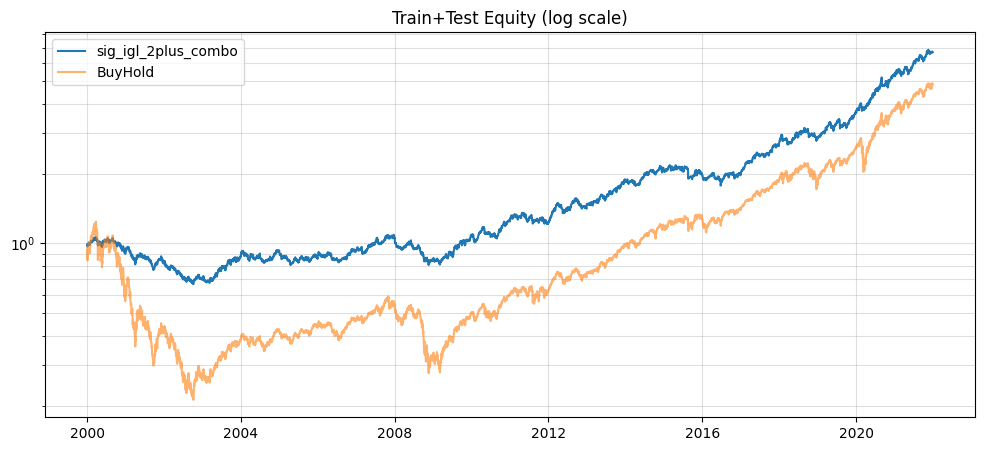

,Holdout
Sharpe,0.994742
Calmar,0.740261
TotalRet,0.807654
MaxDD,-0.174332
AnnVol,0.129733
n,1237.000000


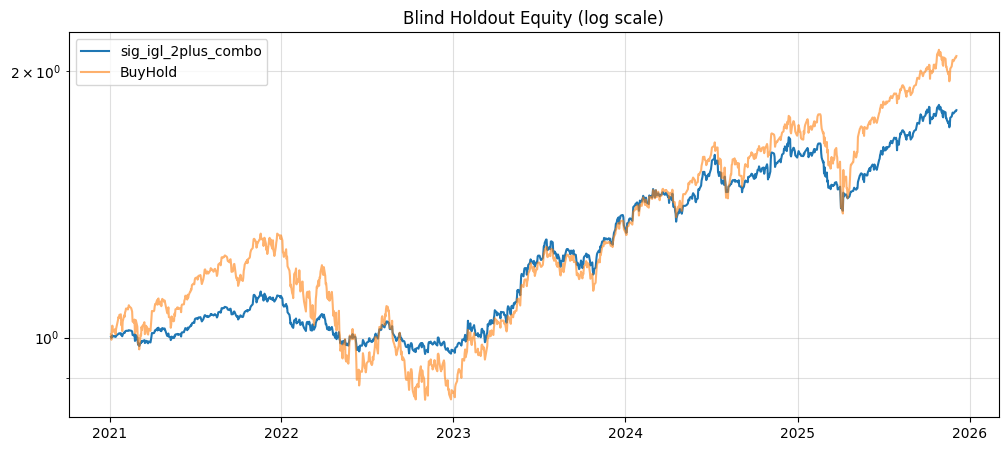


FINAL HOLDOUT SHARPE: 0.99474159202224


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1) Select your FINAL signal
# -----------------------------
# IMPORTANT: Replace this with your actual function name in signals.py
FINAL_SIGNAL_NAME = "sig_igl_2plus_combo"   # e.g. "sig_igl_2plus_combo" or "sig_csgo_simple_mix"

if not hasattr(signals_mod, FINAL_SIGNAL_NAME):
    raise AttributeError(f"signals.py does not contain {FINAL_SIGNAL_NAME}. Available example: {sorted([n for n in dir(signals_mod) if n.startswith('sig_')])[:20]}...")

final_signal_func = getattr(signals_mod, FINAL_SIGNAL_NAME)

# -----------------------------
# 2) Backtester (lev at t applies to close(t)->close(t+1))
# -----------------------------
LEVERAGE_MIN, LEVERAGE_MAX = -1.0, 1.5

def backtest_leverage_signal(df: pd.DataFrame, lev: pd.Series, transaction_cost: float = 0.0005) -> pd.Series:
    df = df.sort_index().copy()
    close = df["close"].astype(float)

    lev = lev.reindex(df.index).fillna(0.0).clip(LEVERAGE_MIN, LEVERAGE_MAX)

    # next day's asset return indexed at t
    next_ret = close.pct_change().shift(-1)

    # costs per |Δlev_t|
    turnover = lev.diff().abs()
    turnover.iloc[0] = 0.0
    costs = turnover * transaction_cost

    strat_ret = lev * next_ret - costs

    # last day has no next_ret
    return strat_ret.iloc[:-1]

def calc_metrics(daily_ret: pd.Series) -> dict:
    r = daily_ret.dropna()
    if len(r) < 5:
        return {"Sharpe": 0.0, "Calmar": 0.0, "TotalRet": 0.0, "MaxDD": 0.0, "AnnVol": 0.0, "n": int(len(r))}
    ann_ret = r.mean() * 252
    ann_vol = r.std(ddof=1) * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0.0
    eq = (1.0 + r).cumprod()
    total = float(eq.iloc[-1] - 1.0)
    dd = eq / eq.cummax() - 1.0
    mdd = float(dd.min())
    calmar = float(ann_ret / abs(mdd)) if mdd < 0 else 0.0
    return {"Sharpe": float(sharpe), "Calmar": float(calmar), "TotalRet": total, "MaxDD": mdd, "AnnVol": float(ann_vol), "n": int(len(r))}

# -----------------------------
# 3) Train/Test on TrainValidate CSV
# -----------------------------
TRAIN_START, TRAIN_END = "2000-01-01", "2015-12-31"
TEST_START,  TEST_END  = "2016-01-01", "2021-12-31"

lev_tv = final_signal_func(df_tv)   # signal should be causal already; DO NOT shift here unless your signal is unlagged-by-design
ret_tv = backtest_leverage_signal(df_tv, lev_tv, transaction_cost=0.0005)

tv_train = ret_tv.loc[TRAIN_START:TRAIN_END]
tv_test  = ret_tv.loc[TEST_START:TEST_END]

bh_lev_tv = pd.Series(1.0, index=df_tv.index)
bh_ret_tv = backtest_leverage_signal(df_tv, bh_lev_tv, transaction_cost=0.0)
bh_train = bh_ret_tv.loc[TRAIN_START:TRAIN_END]
bh_test  = bh_ret_tv.loc[TEST_START:TEST_END]

m_train = calc_metrics(tv_train)
m_test  = calc_metrics(tv_test)
m_bh_train = calc_metrics(bh_train)
m_bh_test  = calc_metrics(bh_test)

results_tv = pd.DataFrame(
    {
        "Train": pd.Series(m_train),
        "Test":  pd.Series(m_test),
        "BH Train": pd.Series(m_bh_train),
        "BH Test":  pd.Series(m_bh_test),
    }
)

display(results_tv)

# Equity plot (Train+Test window)
plt.figure(figsize=(12,5))
eq_sig = (1+ret_tv.loc[TRAIN_START:TEST_END].dropna()).cumprod()
eq_bh  = (1+bh_ret_tv.loc[TRAIN_START:TEST_END].dropna()).cumprod()
plt.plot(eq_sig, label=f"{FINAL_SIGNAL_NAME}")
plt.plot(eq_bh,  label="BuyHold", alpha=0.6)
plt.yscale("log")
plt.title("Train+Test Equity (log scale)")
plt.grid(True, which="both", alpha=0.4)
plt.legend()
plt.show()

# -----------------------------
# 4) FINAL HOLDOUT Sharpe on qqq_blind_holdout.csv
# -----------------------------
lev_ho = final_signal_func(df_ho)
ret_ho = backtest_leverage_signal(df_ho, lev_ho, transaction_cost=0.0005)

bh_lev_ho = pd.Series(1.0, index=df_ho.index)
bh_ret_ho = backtest_leverage_signal(df_ho, bh_lev_ho, transaction_cost=0.0)

m_ho = calc_metrics(ret_ho)
m_bh_ho = calc_metrics(bh_ret_ho)

results_ho = pd.DataFrame({"Holdout": pd.Series(m_ho), "BH Holdout": pd.Series(m_bh_ho)})
display(results_ho)

plt.figure(figsize=(12,5))
eq_sig_ho = (1+ret_ho.dropna()).cumprod()
eq_bh_ho  = (1+bh_ret_ho.dropna()).cumprod()
plt.plot(eq_sig_ho, label=f"{FINAL_SIGNAL_NAME}")
plt.plot(eq_bh_ho,  label="BuyHold", alpha=0.6)
plt.yscale("log")
plt.title("Blind Holdout Equity (log scale)")
plt.grid(True, which="both", alpha=0.4)
plt.legend()
plt.show()

print("\nFINAL HOLDOUT SHARPE:", m_ho["Sharpe"])


In [19]:
# -----------------------------
# 1) Imports & robust module loader (FIXED ROOT)
# -----------------------------
from pathlib import Path
import sys, importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# REQUIRED: set these once
FINAL_SIGNAL_NAME = "sig_igl_2plus_combo"   # <-- change if needed
SRC_DIRNAME = "src"

def find_repo_root(start: Path) -> Path:
    """
    Walk upward until we find a directory that looks like the project root:
    contains src/utils.py AND data/raw.
    """
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / "src" / "utils.py").exists() and (p / "data" / "raw").exists():
            return p
    raise FileNotFoundError(
        "Could not find project root (expected src/utils.py and data/raw). "
        f"Started from: {start}"
    )

def load_module_from_path(module_name: str, module_path: Path):
    """Load a .py file as a module (works even if src is not a Python package)."""
    module_path = module_path.resolve()
    if not module_path.exists():
        raise FileNotFoundError(f"Module not found: {module_path}")
    spec = importlib.util.spec_from_file_location(module_name, str(module_path))
    mod = importlib.util.module_from_spec(spec)  # type: ignore
    assert spec and spec.loader
    spec.loader.exec_module(mod)  # type: ignore
    return mod

# If you're running inside notebooks/, this will climb to Quanta_Fellowship_Project/
ROOT = find_repo_root(Path.cwd())
SRC  = (ROOT / SRC_DIRNAME).resolve()

print("CWD          :", Path.cwd())
print("PROJECT ROOT :", ROOT)
print("SRC DIR      :", SRC)

# Ensure src is importable for `from utils import ...` inside signals.py
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# Load utils + signals
utils_mod   = load_module_from_path("utils", SRC / "utils.py")
signals_mod = load_module_from_path("signals", SRC / "signals.py")

print("Loaded utils  :", getattr(utils_mod, "__file__", "<unknown>"))
print("Loaded signals:", getattr(signals_mod, "__file__", "<unknown>"))

# Grab your final signal function
if not hasattr(signals_mod, FINAL_SIGNAL_NAME):
    candidates = sorted([n for n in dir(signals_mod) if n.startswith("sig_")])
    print("\nAvailable signal functions in signals.py:")
    print("\n".join(candidates))
    raise AttributeError(f"signals.py has no function named: {FINAL_SIGNAL_NAME}")

final_signal_func = getattr(signals_mod, FINAL_SIGNAL_NAME)
print("Final signal:", FINAL_SIGNAL_NAME)


CWD          : c:\Users\brijp\OneDrive\Desktop\PersonalProjects\Quanta_Fellowship_Project\notebooks
PROJECT ROOT : C:\Users\brijp\OneDrive\Desktop\PersonalProjects\Quanta_Fellowship_Project
SRC DIR      : C:\Users\brijp\OneDrive\Desktop\PersonalProjects\Quanta_Fellowship_Project\src
Loaded utils  : C:\Users\brijp\OneDrive\Desktop\PersonalProjects\Quanta_Fellowship_Project\src\utils.py
Loaded signals: C:\Users\brijp\OneDrive\Desktop\PersonalProjects\Quanta_Fellowship_Project\src\signals.py
Final signal: sig_igl_2plus_combo


In [20]:
# -----------------------------
# 2) Data loader (robust to different column conventions)
# -----------------------------
def load_qqq_csv(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    # Find date/time column
    date_col = None
    for c in ["Date", "date", "Time", "time", "timestamp", "Datetime", "datetime"]:
        if c in df.columns:
            date_col = c
            break
    if date_col is None:
        raise KeyError(f"Could not find a date/time column in {csv_path.name}. Columns: {list(df.columns)}")

    df[date_col] = pd.to_datetime(df[date_col], errors="coerce", infer_datetime_format=True)
    df = df.dropna(subset=[date_col]).sort_values(date_col).set_index(date_col)

    # Normalize column names to lowercase
    df.columns = [str(c).strip() for c in df.columns]
    # Map common variants
    ren = {}
    for c in df.columns:
        lc = c.lower()
        if lc in ["latest", "close", "adj close", "adjclose"]:
            ren[c] = "close"
        elif lc == "open":
            ren[c] = "open"
        elif lc == "high":
            ren[c] = "high"
        elif lc == "low":
            ren[c] = "low"
        elif lc in ["volume", "vol", "volu"]:
            ren[c] = "volume"
        elif lc in ["change"]:
            ren[c] = "change"
        elif lc in ["prev_close", "prevclose", "previous close"]:
            ren[c] = "prev_close"
        elif lc in ["ret", "return", "returns"]:
            ren[c] = "ret"
    if ren:
        df = df.rename(columns=ren)

    # Coerce core cols to numeric if present
    for c in ["open", "high", "low", "close", "volume", "change", "prev_close", "ret"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # If prev_close is missing but change exists, attempt reconstruct
    if "prev_close" not in df.columns and "change" in df.columns and "close" in df.columns:
        df["prev_close"] = df["close"] - df["change"]

    # If ret missing, compute from close/prev_close if possible
    if "ret" not in df.columns and "close" in df.columns:
        if "prev_close" in df.columns:
            df["ret"] = (df["close"] / df["prev_close"]) - 1.0
        else:
            df["ret"] = df["close"].pct_change()

    # Clean volume
    if "volume" in df.columns:
        df["volume"] = df["volume"].replace(0, np.nan).ffill()

    return df

# -----------------------------
# Paths: data/raw/*.csv (repo layout)
# -----------------------------
TRAIN_VALIDATE_CSV = "qqq_train_validation.csv"
BLIND_HOLDOUT_CSV  = "qqq_blind_holdout.csv"

DATA_DIR = ROOT / "data" / "raw"
train_path   = (DATA_DIR / TRAIN_VALIDATE_CSV).resolve()
holdout_path = (DATA_DIR / BLIND_HOLDOUT_CSV).resolve()

print("DATA_DIR:", DATA_DIR)
print("Train CSV exists :", train_path.exists(), "->", train_path)
print("Holdout CSV exists:", holdout_path.exists(), "->", holdout_path)

df_tv = load_qqq_csv(train_path)
df_ho = load_qqq_csv(holdout_path)

print("Train/Validation range:", df_tv.index.min().date(), "->", df_tv.index.max().date(), "rows:", len(df_tv))
print("Holdout range         :", df_ho.index.min().date(), "->", df_ho.index.max().date(), "rows:", len(df_ho))
print("TV columns:", list(df_tv.columns))


DATA_DIR: C:\Users\brijp\OneDrive\Desktop\PersonalProjects\Quanta_Fellowship_Project\data\raw
Train CSV exists : True -> C:\Users\brijp\OneDrive\Desktop\PersonalProjects\Quanta_Fellowship_Project\data\raw\qqq_train_validation.csv
Holdout CSV exists: True -> C:\Users\brijp\OneDrive\Desktop\PersonalProjects\Quanta_Fellowship_Project\data\raw\qqq_blind_holdout.csv
Train/Validation range: 2000-01-03 -> 2021-12-31 rows: 5536
Holdout range         : 2021-01-04 -> 2025-12-05 rows: 1238
TV columns: ['open', 'high', 'low', 'close', 'change', '%Change', 'volume', 'prev_close', 'ret']


C:\Users\brijp\AppData\Local\Temp\ipykernel_33840\1185075935.py:16: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[date_col] = pd.to_datetime(df[date_col], errors="coerce", infer_datetime_format=True)
C:\Users\brijp\AppData\Local\Temp\ipykernel_33840\1185075935.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[date_col] = pd.to_datetime(df[date_col], errors="coerce", infer_datetime_format=True)
C:\Users\brijp\AppData\Local\Temp\ipykernel_33840\1185075935.py:16: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.

In [22]:
# -----------------------------
# 3) Backtest engine (local copy to avoid import issues)
# -----------------------------
def backtest_leverage_signal(
    df: pd.DataFrame,
    lev: pd.Series,
    transaction_cost: float = .0005,
    lev_min: float = LEVERAGE_MIN,
    lev_max: float = LEVERAGE_MAX,
) -> tuple[pd.DataFrame, dict]:
    """Close-to-close: lev_t applies to close(t)->close(t+1)."""
    df = df.sort_index().copy()
    close = df["close"].astype(float)

    lev = lev.reindex(df.index).fillna(0.0).clip(lev_min, lev_max)

    # next day's asset return at index t
    ret_next = close.pct_change().shift(-1)

    # turnover cost
    lev_diff = lev.diff().abs()
    lev_diff.iloc[0] = 0.0
    costs = lev_diff * float(transaction_cost)

    gross_ret = lev * ret_next
    strat_ret = gross_ret - costs

    # Drop last day (no next return)
    strat_ret = strat_ret.iloc[:-1]
    lev = lev.iloc[:-1]
    costs = costs.iloc[:-1]
    lev_diff = lev_diff.iloc[:-1]

    equity = (1.0 + strat_ret).cumprod()

    stats = {
        "sharpe": float(utils_mod.annualized_sharpe(strat_ret)),
        "calmar": float(utils_mod.calmar_ratio(strat_ret)),
        "total_return": float(equity.iloc[-1] - 1.0) if len(equity) else 0.0,
        "max_drawdown": float(utils_mod.max_drawdown(equity)) if len(equity) else 0.0,
        "n_days": int(len(strat_ret)),
        "avg_turnover": float(lev_diff.mean()) if len(lev_diff) else 0.0,
    }

    out = pd.DataFrame(
        {
            "close": close.loc[strat_ret.index],
            "lev": lev.loc[strat_ret.index],
            "ret": strat_ret,
            "equity": equity,
            "turnover": lev_diff.loc[strat_ret.index],
            "costs": costs.loc[strat_ret.index],
        },
        index=strat_ret.index,
    )
    return out, stats

def slice_metrics(bt_df: pd.DataFrame) -> dict:
    r = bt_df["ret"].dropna()
    if len(r) == 0:
        return {"Sharpe": 0.0, "Calmar": 0.0, "TotalRet": 0.0, "MaxDD": 0.0}
    eq = (1.0 + r).cumprod()
    return {
        "Sharpe": float(utils_mod.annualized_sharpe(r)),
        "Calmar": float(utils_mod.calmar_ratio(r)),
        "TotalRet": float(eq.iloc[-1] - 1.0),
        "MaxDD": float(utils_mod.max_drawdown(eq)),
    }


In [24]:
# -----------------------------
# 4) Evaluate on Train/Validation dataset
# -----------------------------
# IMPORTANT: Do NOT shift lev here if your backtest uses next_ret at index t (it already does).
lev_tv = final_signal_func(df_tv)

# Buy & hold leverage = 1.0
lev_bh = pd.Series(1.0, index=df_tv.index)

bt_tv, stats_tv = backtest_leverage_signal(df_tv, lev_tv, transaction_cost=.0005)
bt_bh, stats_bh = backtest_leverage_signal(df_tv, lev_bh, transaction_cost=0.0)

bt_train = bt_tv.loc[TRAIN_START:TRAIN_END]
bt_test  = bt_tv.loc[TEST_START:TEST_END]

bt_bh_train = bt_bh.loc[TRAIN_START:TRAIN_END]
bt_bh_test  = bt_bh.loc[TEST_START:TEST_END]

row_igl = {"Strategy": FINAL_SIGNAL_NAME, **{f"Train {k}": v for k,v in slice_metrics(bt_train).items()},
           **{f"Test {k}": v for k,v in slice_metrics(bt_test).items()},
           "Avg Turnover": float(bt_tv["turnover"].mean()),
           "n_days_full": int(len(bt_tv))}
row_bh  = {"Strategy": "BuyHold", **{f"Train {k}": v for k,v in slice_metrics(bt_bh_train).items()},
           **{f"Test {k}": v for k,v in slice_metrics(bt_bh_test).items()},
           "Avg Turnover": 0.0,
           "n_days_full": int(len(bt_bh))}

results_tv = pd.DataFrame([row_igl, row_bh]).set_index("Strategy")
results_tv


,Train Sharpe,Train Calmar,Train TotalRet,Train MaxDD,Test Sharpe,Test Calmar,Test TotalRet,Test MaxDD,Avg Turnover,n_days_full
Strategy,,,,,,,,,,
sig_igl_2plus_combo,0.387622,0.116185,0.966450,-0.372223,1.569577,1.890619,2.404011,-0.119974,0.050558,5535
BuyHold,0.197330,0.018193,0.270333,-0.829639,1.150280,0.876663,2.814695,-0.285594,0.000000,5535


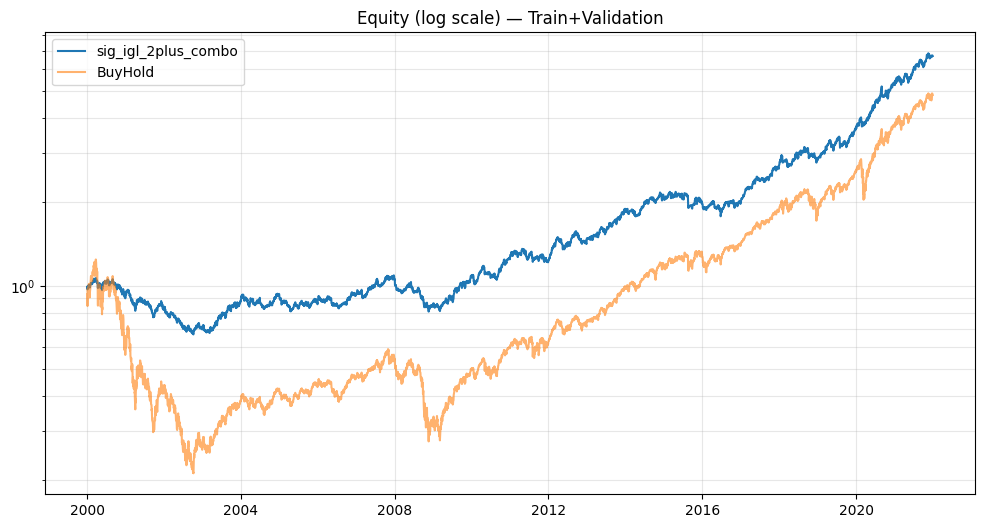

In [25]:
# Plot equity on Train+Validation window
plt.figure(figsize=(12,6))
window = bt_tv.loc[TRAIN_START:TEST_END].dropna()
window_bh = bt_bh.loc[TRAIN_START:TEST_END].dropna()

plt.plot(window["equity"], label=FINAL_SIGNAL_NAME)
plt.plot(window_bh["equity"], label="BuyHold", alpha=0.6)
plt.yscale("log")
plt.title("Equity (log scale) — Train+Validation")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()


In [27]:
# -----------------------------
# 5) Final evaluation on Blind Holdout (final Sharpe)
# -----------------------------
lev_ho = final_signal_func(df_ho)
lev_ho_bh = pd.Series(1.0, index=df_ho.index)

bt_ho, stats_ho = backtest_leverage_signal(df_ho, lev_ho, transaction_cost=.0005)
bt_ho_bh, stats_ho_bh = backtest_leverage_signal(df_ho, lev_ho_bh, transaction_cost=0.0)

holdout_summary = pd.DataFrame(
    [
        {"Strategy": FINAL_SIGNAL_NAME,
         "Sharpe": slice_metrics(bt_ho)["Sharpe"],
         "Calmar": slice_metrics(bt_ho)["Calmar"],
         "TotalRet": slice_metrics(bt_ho)["TotalRet"],
         "MaxDD": slice_metrics(bt_ho)["MaxDD"],
         "Avg Turnover": float(bt_ho["turnover"].mean()),
         "n_days": int(len(bt_ho))},
        {"Strategy": "BuyHold",
         "Sharpe": slice_metrics(bt_ho_bh)["Sharpe"],
         "Calmar": slice_metrics(bt_ho_bh)["Calmar"],
         "TotalRet": slice_metrics(bt_ho_bh)["TotalRet"],
         "MaxDD": slice_metrics(bt_ho_bh)["MaxDD"],
         "Avg Turnover": 0.0,
         "n_days": int(len(bt_ho_bh))}
    ]
).set_index("Strategy")

holdout_summary


,Sharpe,Calmar,TotalRet,MaxDD,Avg Turnover,n_days
Strategy,,,,,,
sig_igl_2plus_combo,0.994742,0.735275,0.807654,-0.174332,0.043242,1237
BuyHold,0.769446,0.458527,1.081119,-0.351187,0.000000,1237
